In [22]:
import pandas as pd
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,recall_score,f1_score
df=pd.read_csv("titanic.csv",usecols=["Age","Fare","Sex","sibsp","Embarked","Parch","Pclass","2urvived"])
df.rename(columns={'2urvived': 'survived'}, inplace=True)

In [23]:
#Filling nulls
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [24]:
from sklearn.preprocessing import LabelEncoder
oe= LabelEncoder()
df['Embarked']=oe.fit_transform(df['Embarked'])
df['Sex']=oe.fit_transform(df['Sex'])

In [25]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df[[ 'Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked']] = sc.fit_transform(df[[ 'Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked']])

In [26]:
from sklearn.model_selection import train_test_split

# Features (X) aur Target (y)
X = df.iloc[:, :-1]  
y = df.iloc[:, -1]    

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      
    random_state=42     
)


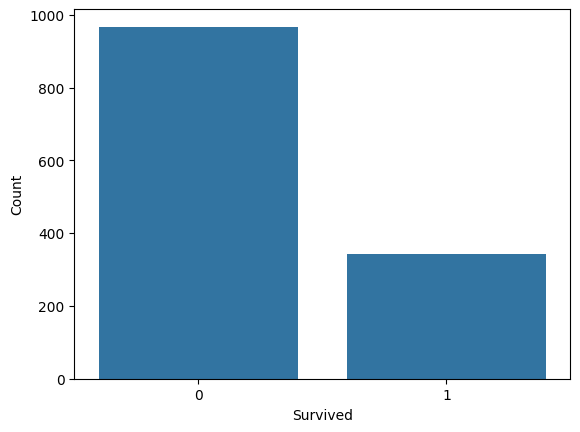

In [27]:
import seaborn as sns 
import matplotlib.pyplot as plt
sns.countplot(x='survived', data=df)
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

In [29]:
from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
random_search = RandomizedSearchCV(
    lr,
    param_grid,
    n_iter=5,
    cv=5,
    scoring='f1',
    random_state=42
)
lr.fit(X_train,y_train)
pred=lr.predict(X_test)

In [30]:
accuracy = accuracy_score(y_test, pred)
cm = confusion_matrix(y_test, pred)
cr = classification_report(y_test, pred)

In [31]:
accuracy = accuracy_score(y_test, pred)
cm = confusion_matrix(y_test, pred)
cr = classification_report(y_test, pred)
print("Accuracy",accuracy)
print("confusion_matrix",cm)
print("classification_report",cr)

Accuracy 0.767175572519084
confusion_matrix [[174  15]
 [ 46  27]]
classification_report               precision    recall  f1-score   support

           0       0.79      0.92      0.85       189
           1       0.64      0.37      0.47        73

    accuracy                           0.77       262
   macro avg       0.72      0.65      0.66       262
weighted avg       0.75      0.77      0.74       262



In [32]:
print("Recall:",recall_score(y_test,pred))
print("F1 Score:",f1_score(y_test,pred))


Recall: 0.3698630136986301
F1 Score: 0.46956521739130436


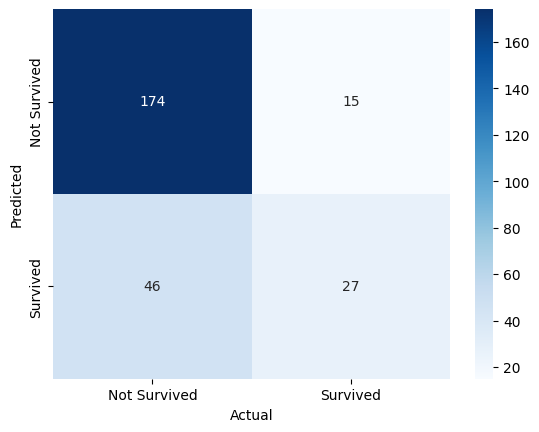

In [33]:
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=["Not Survived","Survived"],
    yticklabels=["Not Survived","Survived"])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

As we have 70% negative class and 30% of positive class, the model have more learn about the negative class and will overfit on negative class , then the majority class leads to bad accuracy and recall score of 36%, NOw we will balance the classes and see the difference how balance classes have good accuracy 

In [34]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

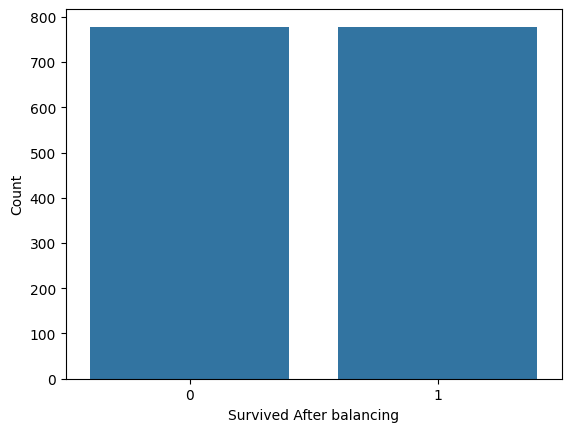

In [35]:
sns.countplot(x=y_train_smote)
plt.xlabel("Survived After balancing")
plt.ylabel("Count")
plt.show()

In [36]:
from sklearn.model_selection import RandomizedSearchCV

lr = LogisticRegression()
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
random_search = RandomizedSearchCV(
    lr,
    param_grid,
    n_iter=5,
    cv=5,
    scoring='f1',
    random_state=42
)
lr.fit(X_train_smote, y_train_smote)
pred_smote=lr.predict(X_test)

In [37]:
accuracy_smote = accuracy_score(y_test, pred_smote)
cm_smote = confusion_matrix(y_test, pred_smote)
cr_smote = classification_report(y_test, pred_smote)
print("Accuracy",accuracy_smote)
print("confusion_matrix",cm_smote)
print("classification_report",cr_smote)

Accuracy 0.7404580152671756
confusion_matrix [[138  51]
 [ 17  56]]
classification_report               precision    recall  f1-score   support

           0       0.89      0.73      0.80       189
           1       0.52      0.77      0.62        73

    accuracy                           0.74       262
   macro avg       0.71      0.75      0.71       262
weighted avg       0.79      0.74      0.75       262



In [ ]:
print("Recall:",recall_score(y_test, pred_smote))
print("F1 Score:",f1_score(y_test, pred_smote))

Recall: 0.7671232876712328
F1 Score: 0.6222222222222222


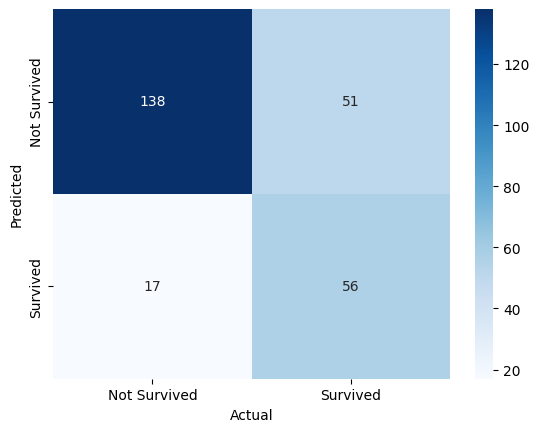

In [38]:
sns.heatmap(cm_smote,annot=True,fmt='d',cmap='Blues',xticklabels=["Not Survived","Survived"],
    yticklabels=["Not Survived","Survived"])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    model,
    param_grid,
    n_iter=5,
    cv=5,
    scoring='f1',
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

NOw you can see balance classes have recall of 76% although the accuracy has decreased as both classes balanced but from confusion matrics you can see no of TP has incresed to 56 